# Statistics and metrics to evaluate 

## Possible Metrics 

1. rMSE / MAE / NRMSE, Error growth curve i.e. error vs time --> NRMSE
2. Valid prediction time --> Time before it exceeds a certain threshold 
3. Difference between invariant measure - how to compute? 
4. Moment matching over long rollouts (mean, variance?)
5. Temporal power spectral density
6. Lyapunov exponents 
7. CRPS - not really probabilistic...
8. Plot function of "drivers" and evaluate it's difference --> similar to dysts metric 
9. Convergence ratio

## Procedure 

1. train on ~5 trajectories - test on the other trajectories. Worth training on all trajectories together? 
2. Compute following metrics: NRMSE i.e. sqrt(1/T sum(x - x)^2 ); VPT; Temporal power spectral density; Plot function of "drivers" and evaluate it's difference
Invariant measure / Lyapunov exponents --> need to generate own data, trajectories of ~ > 10_000 steps 
Inv measure: Kernel density estimate, on all data points except first 200 -- then use Jensen Shannon divergence OR Wasserstein distance directly on samples 
Lyapunov exponents : do I have access to the CausalDynamics equations? yes, access to jacobian / differentiable model --> Benettin's algorithm



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
import numpy as np
import xarray as xr

# from causaldynamics.scm import create_scm_graph
# from causaldynamics.plot import plot_scm
# from causaldynamics.score import score
# from causaldynamics.baselines import PCMCIPlus
# from causaldynamics.baselines import FPCMCI
# from causaldynamics.baselines import DYNOTEARS
# from causaldynamics.baselines import VARLiNGAM
# from causaldynamics.baselines import NGC_LSTM
# from causaldynamics.baselines import TSCI
# from causaldynamics.baselines import CUTSPlus
# # from causaldynamics.baselines import RCD
# # from causaldynamics.baselines import GIN
# # from causaldynamics.baselines import GRASP
# from causaldynamics.baselines import TCDF

# DYNOTEARS / FPCMCI + not sure about PCMCIPlus + VARLiNGAM

from tqdm import tqdm
from pathlib import Path
import torch

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 
from causaldynamics.metrics import valid_prediction_time, nrmse_vs_time, log_spectral_distance, wasserstein_distance, nn_lyapunov_exponents_delta, true_lyapunov_exponents, dstsp, correlation_dimension_error

In [3]:
from causaldynamics.baselines import PICABU, StructuredLowRankDiscovery, StructuredODEDiscovery, StructuredODEDiscoveryAGL, StructuredODEDiscoveryPathReg
from causaldynamics.run_dysts import run_dysts

In [4]:
import dysts.flows as flows

system_name = "SprottTorus"  # e.g. "Lorenz" or "SprottA"
system = getattr(flows, system_name)()
tpts, trajectory = system.make_trajectory(10, return_times=True)
print(np.array(system.jac(trajectory[0], 0)))

[[ 0.22504432  2.3766952   0.6883476 ]
 [-2.7533904   0.58539724 -0.18017646]
 [-0.3766952   0.36035292  0.        ]]


In [5]:
dict_result = run_dysts(system_name, save_fig_path = f'test_{system_name}.png')


Make trajectories
Training 
Train AGL
Dimensions: N=3, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], dtype=torch.int64),)
X_t_all.shape: torch.Size([999, 1, 3])
X_last_all.shape: torch.Size([999, 1, 3])
recon=1.0014  grad_penalty=0.0000  
train L0
Dimensions: N=3, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], dtype=torch.int64),)
X_t_all.shape: torch.Size([999, 1, 3])
X_last_all.shape: torch.Size([999, 1, 3])
  → fixed M at step 996 after 200 no-improve steps; training MLPs until step 1005
recon=0.0457  |M|_1=8.000  grad_penalty=0.0000  
Dimensions: N=3, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], dtype=torch.int64),)
X_t_all.shape: torch.Size([999, 1, 3])
X_last_all.shape: torch.Size([999, 1, 3])
  → fixed M at step 771 after 200 no-improve 

In [6]:
dict_result

{'lyapunov_exponents': array([ 0.09229103,  0.01656962, -0.13211491]),
 'train_trajectory': array([[ 0.6883476 , -0.18017646,  0.58539724],
        [ 0.68484528, -0.18735849,  0.6101049 ],
        [ 0.68122421, -0.1944319 ,  0.63462814],
        ...,
        [-0.21352341,  0.11325907, -0.97983879],
        [-0.17326748,  0.21661085, -1.01525245],
        [-0.12689898,  0.30945863, -1.04846475]]),
 'test_trajectories': array([[[ 0.9932426 , -0.25998338,  0.84469166],
         [ 0.96693974, -0.42767525,  0.83019067],
         [ 0.87358041, -0.58124088,  0.80422997],
         ...,
         [ 0.82572491,  0.01311798,  0.12988105],
         [ 0.83686421, -0.03978094,  0.14878476],
         [ 0.83027995, -0.09496238,  0.16687302]],
 
        [[ 0.81032063, -0.21210316,  0.68912779],
         [ 0.79993614, -0.27637664,  0.70217387],
         [ 0.76790769, -0.33795856,  0.71214466],
         ...,
         [ 0.67960558,  0.09650854, -0.37991536],
         [ 0.67772428,  0.10243138, -0.3515622 ]

In [ ]:
dict_result["predictions"]['l0'].shape

(3, 5000, 3)

In [ ]:
(np.sqrt(((dict_result["test_trajectories"][:, :] - dict_result["predictions"]['pathreg'][:, :])**2).sum(-1))).mean()

5.058702889800326

In [8]:
lyapunov_exponents = true_lyapunov_exponents(system_name)
lambda_1 = float(lyapunov_exponents[0])
dt = tpts[1] - tpts[0]
1/(lambda_1*dt)

114.63208323195249

In [77]:
# dt = tpts[1] - tpts[0]
114.63208323195249 * 250

28658.020807988123

In [9]:
num_timesteps = 10_000
# trajectory = system.make_trajectory(num_timesteps)
tpts, trajectory = system.make_trajectory(num_timesteps, return_times=True)
dt = tpts[1] - tpts[0]   # resampling is on a uniform Fourier-timescale grid, so this is constant

trajectory.shape

(10000, 3)

In [10]:
print(np.array(system.jac(trajectory[0], 0)))

[[-1.          2.67120019 -0.63022446]
 [ 1.67120019 -1.         -0.77915628]
 [ 0.63022446  0.77915628  0.        ]]


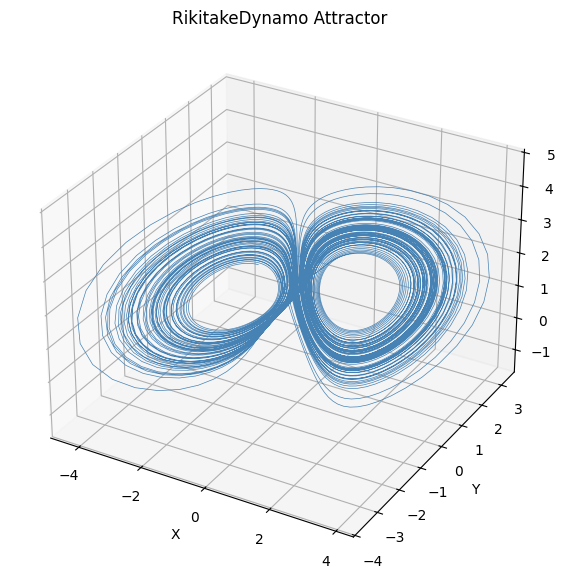

In [11]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(trajectory[:, 0], trajectory[:, 1], trajectory[:, 2], lw=0.5, color='steelblue')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title(f"{system_name} Attractor")
plt.show()

In [ ]:
# timeseries_stacked = trajectory[None, :, None]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tau_max = 1 # i.e. no delay 

## Estimate adjacency matrix
lowrank_adj_matrix = []

x = trajectory[:5000, None].astype('float32')
lowrank_model = StructuredODEDiscoveryAGL(
    coupled=False,
    t = tau_max,
    n = 3,
    hidden_dim = 8, 
    n_layers = 2,
    device = device,
    normalize_grad = True,
)
# 100.0	1.000
trained_model_agl, mask_agl = lowrank_model.run(lambda_grad=100, X=torch.tensor(x).to(device), lambda_init = 0., lambda_m = 0.01, lr=0.001, n_inner_min_sparse = 100, batch_size=128, n_inner=1_000, patience = 1000, save_fig_path="agl_loss.png")
# print(mask_agl)
lowrank_model = StructuredODEDiscovery(
    coupled=False,
    t = tau_max,
    n = 3,
    L_lipschitz = 1, 
    is_lipschitz = True,
    hidden_dim = 8, 
    n_layers = 2,
    device = device,
    beta_init = 0.33, 
    beta_min = 0.33,
    annealing_rate = 0.95,
    annealing_epochs = 10,
    normalize_grad = True,
)
trained_model, mask = lowrank_model.run(n_samples=3, lambda_grad=0, X=torch.tensor(x).to(device), l0_l1_l2='l0', th=0.5, lr=0.001, lambda_m = 0.005, n_inner_min_sparse = 100, batch_size=128, n_inner=4_000, patience = 200, save_fig_path=f"dysts_{system_name}_system.png")
lowrank_model = StructuredODEDiscovery(
    coupled=False,
    t = tau_max,
    n = 3,
    L_lipschitz = 1, 
    is_lipschitz = False,
    hidden_dim = 8, 
    n_layers = 2,
    device = device,
    beta_init = 0.33, 
    beta_min = 0.33,
    annealing_rate = 0.95,
    annealing_epochs = 10,
    normalize_grad = True,
)
trained_model_l1, mask_l1 = lowrank_model.run(n_samples=5, lambda_grad=10, X=torch.tensor(x).to(device), l0_l1_l2='l1', th=0.5, lr=0.001, lambda_m = 50., n_inner_min_sparse = 100, batch_size=128, n_inner=2_000, patience = 200, save_fig_path="couple_005_loss.png")
lowrank_adj_matrix.append(mask.detach().cpu().numpy())
# lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))

# print(mask)

Dimensions: N=3, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], dtype=torch.int64),)
X_t_all.shape: torch.Size([4999, 1, 3])
X_last_all.shape: torch.Size([4999, 1, 3])
  → fixed M at step 415 after 200 no-improve steps; training MLPs until step 815
recon=0.1579  |M|_1=8.000  grad_penalty=0.0002  


In [13]:
# lowrank_model.model.fixed_M
torch.sigmoid(lowrank_model.model.M_logits)
# trained_model = lowrank_model.model

# mask

tensor([[[9.1798e-01, 8.6251e-01, 8.0682e-01],
         [8.8636e-01, 8.4502e-01, 9.4877e-01],
         [9.4380e-01, 9.3382e-01, 1.0442e-07]]], grad_fn=<SigmoidBackward0>)

In [14]:
lowrank_model = StructuredODEDiscoveryPathReg(
    coupled=False,
    t = tau_max,
    n = 3,
    hidden_dim = 8, 
    n_layers = 2,
    device = device,
    normalize_grad = True,
)
trained_model_pathreg, mask_pathreg = lowrank_model.run(lambda_grad=0, X=torch.tensor(x).to(device), lr=0.001, lambda_path = 1., n_inner_min_sparse = 50, batch_size=128, n_inner=2_000, patience = 200, save_fig_path="pathreg_loss.png")
print(mask_pathreg)

tensor([[0.1858, 0.1901, 0.2010],
        [0.1866, 0.1905, 0.1952],
        [0.1837, 0.1769, 0.1914]], grad_fn=<StackBackward0>)


In [15]:
x = torch.tensor(x).to(device)
x = x - x.mean(dim=0, keepdim=True)
x = x / (x.std(dim=0, keepdim=True) + 1e-8) # Small fix


In [16]:
X_last_all = x[1:] - x[:-1]
std_grad = X_last_all.std((0, 1))
# std_grad[std_grad < 1e-6] = 1.0
mean_grad = X_last_all.mean((0, 1))
# X_last_all = X_last_all / std_grad
# std_grad, mean_grad = 1, 0

In [19]:
input_train_data = x.detach().cpu().numpy()
next_pred = trained_model.infer(x[:-1])
prediction = (x[:-1] + next_pred * std_grad + mean_grad).detach().cpu().numpy()

prediction = prediction[:, 0]
input_train_data = input_train_data[1:, 0]

print(((prediction - input_train_data)**2).mean())


input_train_data = x.detach().cpu().numpy()
next_pred = trained_model_pathreg.infer(x[:-1])
prediction_pathreg = (x[:-1] + next_pred * std_grad + mean_grad).detach().cpu().numpy()

prediction_pathreg = prediction_pathreg[:, 0]
input_train_data = input_train_data[1:, 0]

print(((prediction_pathreg - input_train_data)**2).mean())

# # input_train_data = x.detach().cpu().numpy()
# # next_pred = trained_model_l1.infer(x[:-1])
# # prediction_l1 = (x[:-1] + next_pred * std_grad + mean_grad).detach().cpu().numpy()

# # prediction_l1 = prediction_l1[:, 0]
# # input_train_data = input_train_data[1:, 0]

# # print(((prediction_l1 - input_train_data)**2).mean())

# input_train_data = x.detach().cpu().numpy()
# next_pred = trained_model_agl.infer(x[:-1])
# prediction_agl = (x[:-1] + next_pred * std_grad + mean_grad).detach().cpu().numpy()

# prediction_agl = prediction_agl[:, 0]
# input_train_data = input_train_data[1:, 0]

# print(((prediction_agl - input_train_data)**2).mean())


0.0070519503
0.0075597833


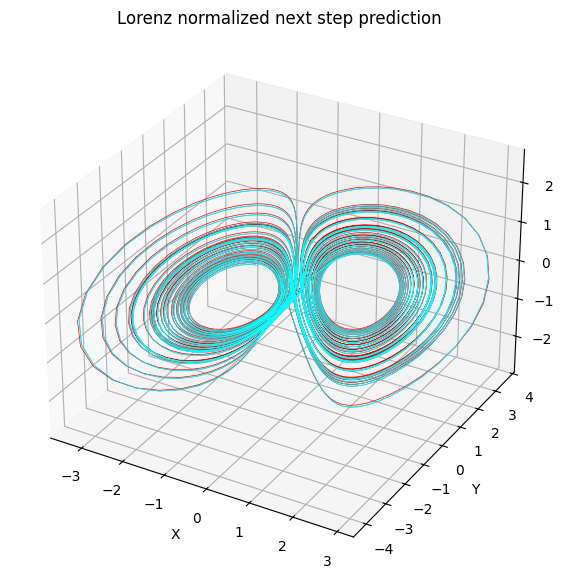

In [20]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(input_train_data[:, 0], input_train_data[:, 1], input_train_data[:, 2], lw=0.5, color='steelblue')
ax.plot(prediction[:, 0], prediction[:, 1], prediction[:, 2], lw=0.5, color='red')
ax.plot(prediction_pathreg[:, 0], prediction_pathreg[:, 1], prediction_pathreg[:, 2], lw=0.5, color='cyan')
# ax.plot(prediction_l1[:, 0], prediction_l1[:, 1], prediction_l1[:, 2], lw=0.5, color='green')
# ax.plot(prediction_agl[:, 0], prediction_agl[:, 1], prediction_agl[:, 2], lw=0.5, color='goldenrod')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title("Lorenz normalized next step prediction")
plt.show()


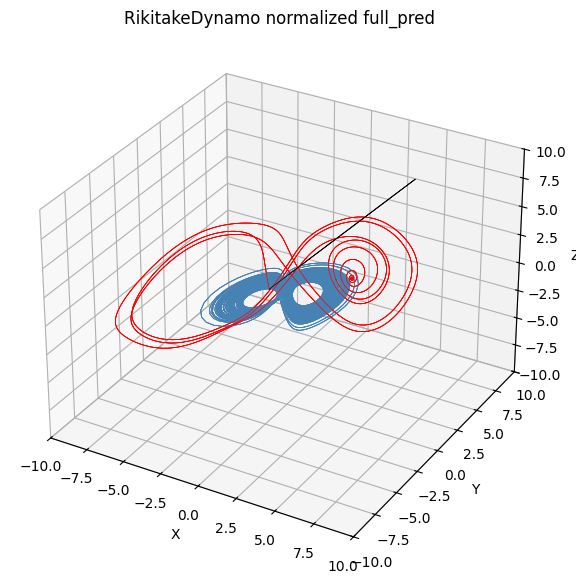

In [70]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Take 80 different start points, and predict 1000 timesteps 

for start_time in np.arange(1, 5): # 80
    start_time = start_time*50 + 5000
    test_timeseries = trajectory.copy() #[start_time:start_time+4000]

    test_timeseries = test_timeseries - test_timeseries.mean(0) #.detach().cpu().numpy()
    test_timeseries = test_timeseries / test_timeseries.std(0) #.detach().cpu().numpy() # Small fix


    test_timeseries = torch.tensor(test_timeseries, device = device)
    full_predictions = torch.zeros(test_timeseries.shape, device = device) 
    # full_predictions_l1 = torch.zeros(test_timeseries.shape, device = device) 
    # full_predictions_agl = torch.zeros(test_timeseries.shape, device = device) 
    full_predictions_pathreg = torch.zeros(test_timeseries.shape, device = device) 
    full_predictions[0] = test_timeseries[0]
    # full_predictions_l1[0] = test_timeseries[0]
    # full_predictions_agl[0] = test_timeseries[0]
    full_predictions_pathreg[0] = test_timeseries[0]

    for k in np.arange(1, len(test_timeseries)):
        initial_cond = full_predictions[k-1]
        diff = trained_model.infer(initial_cond[None])[0]
        full_predictions[k] = initial_cond + diff * std_grad + mean_grad
        # initial_cond = full_predictions_l1[k-1]
        # diff = trained_model_l1.infer(initial_cond[None])[0]
        # full_predictions_l1[k] = initial_cond + diff * std_grad + mean_grad
        # initial_cond = full_predictions_agl[k-1]
        # diff = trained_model_agl.infer(initial_cond[None])[0]
        # full_predictions_agl[k] = initial_cond + diff * std_grad + mean_grad
        initial_cond = full_predictions_pathreg[k-1]
        diff = trained_model_pathreg.infer(initial_cond[None])[0]
        full_predictions_pathreg[k] = initial_cond + diff * std_grad + mean_grad

    full_predictions = full_predictions.detach().cpu().numpy()
    # full_predictions_l1 = full_predictions_l1.detach().cpu().numpy()
    # full_predictions_agl = full_predictions_agl.detach().cpu().numpy()
    full_predictions_pathreg = full_predictions_pathreg.detach().cpu().numpy()
    test_timeseries = test_timeseries.detach().cpu().numpy()

    ax.plot(test_timeseries[:, 0], test_timeseries[:, 1], test_timeseries[:, 2], lw=0.5, color='steelblue')
    # ax.plot(input_train_data[:, 0], input_train_data[:, 1], input_train_data[:, 2], lw=0.5, color='green')
    ax.plot(full_predictions[:, 0], full_predictions[:, 1], full_predictions[:, 2], lw=0.5, color='red')
    ax.plot(full_predictions_pathreg[:, 0], full_predictions_pathreg[:, 1], full_predictions_pathreg[:, 2], lw=0.5, color='black')
    # ax.plot(full_predictions_agl[:, 0], full_predictions_agl[:, 1], full_predictions_agl[:, 2], lw=0.5, color='goldenrod')
    # ax.plot(full_predictions_l1[:5000, 0], full_predictions_l1[:5000, 1], full_predictions_l1[:5000, 2], lw=0.5, color='green')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title(f"{system_name} normalized full_pred")

ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])
plt.show()





In [71]:
print(dstsp(full_predictions[None], test_timeseries[None]))
print(dstsp(full_predictions_pathreg[None], test_timeseries[None]))

print(correlation_dimension_error(full_predictions[None], test_timeseries[None]))
print(correlation_dimension_error(full_predictions_pathreg[None], test_timeseries[None]))

# correlation_dimension_error

6.653000396285012
20.056361016596572
1.2797739741376
0.8070247230596213


In [73]:
full_predictions.shape

(10000, 3)

In [75]:
print(dstsp(full_predictions[None], test_timeseries[None]))
print(dstsp(full_predictions_pathreg[None], test_timeseries[None]))

print(correlation_dimension_error(full_predictions[None], test_timeseries[None]))
print(correlation_dimension_error(full_predictions_pathreg[None], test_timeseries[None]))

# correlation_dimension_error

32.17183566192998
40.742949120121274
1.2797739741376
0.8070247230596213


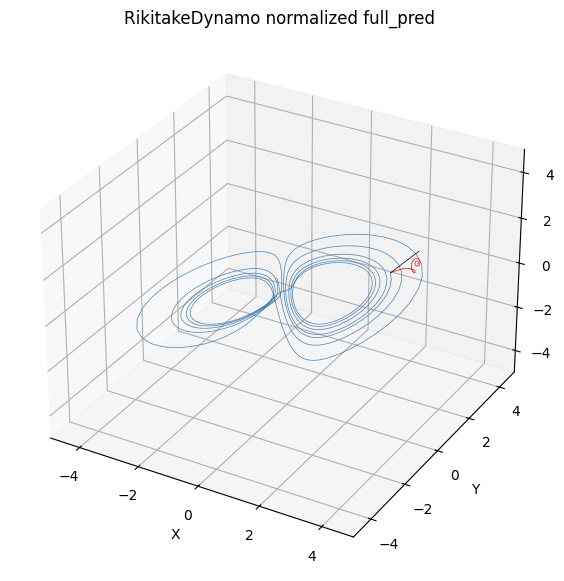

In [25]:

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot(test_timeseries[:, 0], test_timeseries[:, 1], test_timeseries[:, 2], lw=0.5, color='steelblue')
# ax.plot(input_train_data[:, 0], input_train_data[:, 1], input_train_data[:, 2], lw=0.5, color='green')
ax.plot(full_predictions[:, 0], full_predictions[:, 1], full_predictions[:, 2], lw=0.5, color='red')
ax.plot(full_predictions_pathreg[:, 0], full_predictions_pathreg[:, 1], full_predictions_pathreg[:, 2], lw=0.5, color='black')
# ax.plot(full_predictions_agl[:, 0], full_predictions_agl[:, 1], full_predictions_agl[:, 2], lw=0.5, color='goldenrod')
# ax.plot(full_predictions_l1[:5000, 0], full_predictions_l1[:5000, 1], full_predictions_l1[:5000, 2], lw=0.5, color='green')
ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
ax.set_title(f"{system_name} normalized full_pred")
ax.set_xlim([-5, 5])
ax.set_ylim([-5, 5])
ax.set_zlim([-5, 5])
plt.show()


In [143]:
# Compute metrics


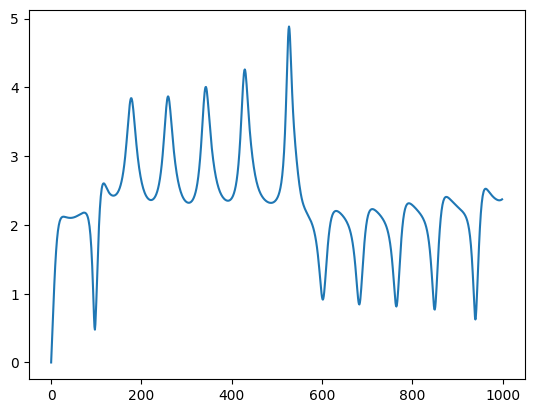

1.7785621514825984
VPT 7.0
LSD 13.447978387659353
Wasserstein distance 4.1019312140769655


In [27]:
nrmse_error = nrmse_vs_time(test_timeseries[None], full_predictions[None])
plt.figure()
plt.plot(nrmse_error)
plt.show()
plt.close()
print(nrmse_error[:50].mean())
vpt = valid_prediction_time(test_timeseries[None], full_predictions[None], threshold=1)
print(f"VPT {vpt}")
lsd = log_spectral_distance(test_timeseries[None], full_predictions[None])
print(f"LSD {lsd}")
waser_dist = wasserstein_distance(test_timeseries[None], full_predictions[None])
print(f"Wasserstein distance {waser_dist}")


In [29]:
# nrmse_error = nrmse_vs_time(test_timeseries[None], full_predictions_l1[None])
# plt.figure()
# plt.plot(nrmse_error)
# plt.show()
# plt.close()
# vpt = valid_prediction_time(test_timeseries[None], full_predictions_l1[None], threshold=1)
# print(f"VPT {vpt}")
# lsd = log_spectral_distance(test_timeseries[None], full_predictions_l1[None])
# print(f"LSD {lsd}")
# waser_dist = wasserstein_distance(test_timeseries[None], full_predictions_l1[None])
# print(f"Wasserstein distance {waser_dist}")


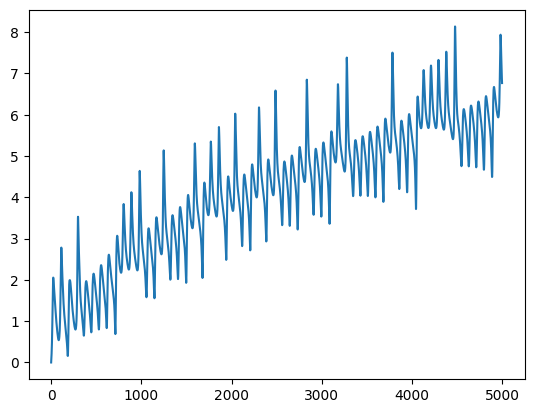

1.3079008802565155
VPT 14.0
LSD 16.62122503640469
Wasserstein distance 8.038407829602566


In [52]:
nrmse_error = nrmse_vs_time(test_timeseries[None], full_predictions_agl[None])
plt.figure()
plt.plot(nrmse_error)
plt.show()
plt.close()
print(nrmse_error[:50].mean())
vpt = valid_prediction_time(test_timeseries[None], full_predictions_agl[None], threshold=1)
print(f"VPT {vpt}")
lsd = log_spectral_distance(test_timeseries[None], full_predictions_agl[None])
print(f"LSD {lsd}")
waser_dist = wasserstein_distance(test_timeseries[None], full_predictions_agl[None])
print(f"Wasserstein distance {waser_dist}")


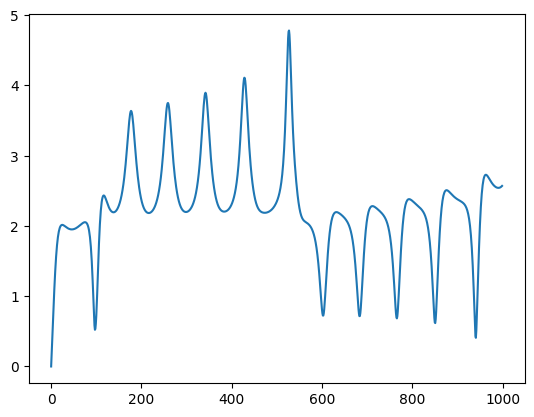

1.6828013968103415
VPT 7.0
LSD 10.931671049705463
Wasserstein distance 4.08600718776567


In [ ]:
# full_predictions_pathreg = full_predictions_pathreg.detach().cpu().numpy()
nrmse_error = nrmse_vs_time(test_timeseries[None], full_predictions_pathreg[None])
plt.figure()
plt.plot(nrmse_error)
plt.show()
plt.close()
print(nrmse_error[:50].mean())
vpt = valid_prediction_time(test_timeseries[None], full_predictions_pathreg[None], threshold=1)
print(f"VPT {vpt}")
lsd = log_spectral_distance(test_timeseries[None], full_predictions_pathreg[None])
print(f"LSD {lsd}")
waser_dist = wasserstein_distance(test_timeseries[None], full_predictions_pathreg[None])
print(f"Wasserstein distance {waser_dist}")


In [ ]:
test_timeseries = trajectory[5000:]

test_timeseries = test_timeseries - test_timeseries.mean(0) #.detach().cpu().numpy()
test_timeseries = test_timeseries / test_timeseries.std(0) #.detach().cpu().numpy() # Small fix


test_timeseries = torch.tensor(test_timeseries, device = device)

initial_cond = test_timeseries[0]
initial_cond

tensor([-1.2529, -0.5541,  1.3275], device='cuda:0', dtype=torch.float64)

In [47]:

input_test_data = trajectory[5000:].astype('float32')

lyapunov_exp_true = true_lyapunov_exponents(system)
lyapunov_exp_l0 = nn_lyapunov_exponents_delta(trained_model, torch.tensor(input_test_data, device = device), mean_grad, std_grad, num_steps=len(input_test_data) - 1000, t_burn=500, dt=dt)
# lyapunov_exp_l1 = nn_lyapunov_exponents_delta(trained_model_l1, torch.tensor(full_predictions_l1, device = device), mean_grad, std_grad, num_steps=2000, t_burn=500, dt=dt)
# lyapunov_exp_agl = nn_lyapunov_exponents_delta(trained_model_agl, torch.tensor(full_predictions_agl, device = device), mean_grad, std_grad, num_steps=2000, t_burn=500, dt=dt)
lyapunov_exp_pathreg = nn_lyapunov_exponents_delta(trained_model_pathreg, torch.tensor(input_test_data, device = device), mean_grad, std_grad, num_steps=len(input_test_data) - 1000, t_burn=500, dt=dt)

# first_error_exponent_l0 = np.abs(lyapunov_exp_true[0] - lyapunov_exp_l0[0])/np.abs(lyapunov_exp_true[0])
# first_error_exponent_l1 = np.abs(lyapunov_exp_true[0] - lyapunov_exp_l1[0])/np.abs(lyapunov_exp_true[0])
# first_error_exponent_agl = np.abs(lyapunov_exp_true[0] - lyapunov_exp_agl[0])/np.abs(lyapunov_exp_true[0])


# sum_of_exp_true = lyapunov_exp_true.sum()
# sum_of_exp_error_l0 = np.abs(lyapunov_exp_l0 - sum_of_exp_true) 
# sum_of_exp_error_l1 = np.abs(lyapunov_exp_l1 - sum_of_exp_true) 
# sum_of_exp_error_agl = np.abs(lyapunov_exp_agl - sum_of_exp_true) 

# kyd_true = lyapunov_exp_true[:2].sum() / np.abs(lyapunov_exp_true[2])
# kyd_error_l0 = np.abs(lyapunov_exp_l0[:2].sum() / np.abs(lyapunov_exp_l0[2]) - kyd_true)
# kyd_error_agl = np.abs(lyapunov_exp_agl[:2].sum() / np.abs(lyapunov_exp_agl[2]) - kyd_true)
# kyd_error_l1 = np.abs(lyapunov_exp_l1[:2].sum() / np.abs(lyapunov_exp_l1[2]) - kyd_true)


For Lyapunov exponents: 
- error in the first exponent --> Lyapunov time --> report relative error 
Sum of expoents phase-space contraction rate, dissipativity
Kaplan Yorke dimension --> attractor dimension 

In [48]:
lyapunov_exp_l0

array([ 0.01943982, -0.01070751, -0.20637239])

In [49]:
lyapunov_exp_pathreg

array([ 6.65984651e-11, -2.32179264e-10, -1.01040982e-06])

In [50]:
lyapunov_exp_true

array([ 0.13312768,  0.01176624, -2.14489392])

In [44]:
input_test_data.shape

(0, 3)

In [52]:
2 + (0.13312768 + 0.01176624)/2.14489392

2.06755295385424

## Load dysts hyperparameter search results

Loads the per-(system, method, lambda_grad, penalty) NPZ files saved by `scripts/run_hyperparam_search_dysts.py` and organizes them into one DataFrame per method.

In [4]:
import re
import pandas as pd

HYPERPARAM_SEARCH_DIR = Path("../scripts/hyperparam_search_dysts")

_RESULT_FILENAME_RE = re.compile(r"^(?P<system>.+)__(?P<method>.+)_lg(?P<lambda_grad>[-\d.]+)_pen(?P<penalty>[-\d.]+)\.npz$")


def load_hyperparam_search_results(results_dir):
    """Load every per-(system, method, lambda_grad, penalty) NPZ file in
    results_dir into a single long-format DataFrame."""
    rows = []
    for path in sorted(Path(results_dir).glob("*.npz")):
        match = _RESULT_FILENAME_RE.match(path.name)
        if match is None:
            continue  # skip systems_used.npz, best_hyperparams.npz, etc.
        data = np.load(path)
        rows.append({
            "system": str(data["system"]),
            "method": match.group("method"),
            "lambda_grad": float(data["lambda_grad"]),
            "penalty": float(data["penalty"]),
            "nrmse": float(data["nrmse"]),
            "vpt": float(data["vpt"]),
            "lsd": float(data["lsd"]),
            "wasserstein": float(data["wasserstein"]),
        })
    return pd.DataFrame(rows)


results_df = load_hyperparam_search_results(HYPERPARAM_SEARCH_DIR)
results_df.shape

(852, 8)

In [5]:
results_by_method = {
    method: df.reset_index(drop=True)
    for method, df in results_df.groupby("method")
}

for method, df in results_by_method.items():
    print(f"{method}: {len(df)} rows, {df['system'].nunique()} systems")

# results_by_method["agl"].head()

C-NODE: 209 rows, 9 systems
L0-NODE: 180 rows, 9 systems
No grad reg.: 40 rows, 8 systems
agl: 225 rows, 9 systems
pathreg: 198 rows, 8 systems


In [118]:
pd.set_option('display.max_rows', None)
results_df[results_df["system"] == "RikitakeDynamo"]

,system,method,lambda_grad,penalty,nrmse,vpt,lsd,wasserstein
352,RikitakeDynamo,C-NODE,0.0,0.500,2.372595,8.333333,41.888828,141.491324
353,RikitakeDynamo,C-NODE,0.0,1.000,3.692363,6.333333,44.860906,235.129317
354,RikitakeDynamo,C-NODE,0.0,10.000,2.981970,7.000000,46.592530,241.194962
355,RikitakeDynamo,C-NODE,0.0,100.000,4.599664,4.333333,49.685634,434.840239
356,RikitakeDynamo,C-NODE,0.0,50.000,4.172181,6.000000,42.004399,334.276912
357,RikitakeDynamo,C-NODE,0.1,0.500,2.865949,6.666667,37.282059,126.753063
358,RikitakeDynamo,C-NODE,0.1,1.000,1.938442,7.333333,37.848862,108.111737
359,RikitakeDynamo,C-NODE,0.1,10.000,4.452479,4.666667,49.118588,359.707424
360,RikitakeDynamo,C-NODE,0.1,100.000,2.444027,16.666667,48.281202,299.470648
361,RikitakeDynamo,C-NODE,0.1,50.000,2.136928,6.000000,43.084957,195.193546


In [11]:
def best_params_by_vpt(results_df):
    """For each method, average nrmse/vpt/lsd/wasserstein across systems for
    every (lambda_grad, penalty) combo, then return the combo with the highest
    average VPT, along with its averaged metrics."""
    avg = results_df.groupby(["method", "lambda_grad", "penalty"], as_index=False).agg(
        nrmse=("nrmse", "median"),
        vpt=("vpt", "median"),
        lsd=("lsd", "median"),
        wasserstein=("wasserstein", "median"),
        n_systems=("system", "nunique"),
    )
    best_idx = avg.groupby("method")["vpt"].idxmax()
    return avg.loc[best_idx].sort_values("method").reset_index(drop=True)


best_params_by_vpt(results_df)

,method,lambda_grad,penalty,nrmse,vpt,lsd,wasserstein,n_systems
0,C-NODE,10.0,1.000,2.141445,9.500000,39.602808,122.079603,8
1,L0-NODE,100.0,0.025,1.027680,37.666667,47.715223,54.096925,9
2,No grad reg.,0.0,0.001,1.346532,39.333333,45.943392,34.303583,8
3,agl,100.0,1.000,1.446074,14.000000,15.388555,1.362235,9
4,pathreg,0.0,0.050,1.318780,14.833333,14.498691,3.440514,8


In [10]:
def best_params_by_wasserstein(results_df):
    """For each method, average nrmse/vpt/lsd/wasserstein across systems for
    every (lambda_grad, penalty) combo, then return the combo with the highest
    average VPT, along with its averaged metrics."""
    avg = results_df.groupby(["method", "lambda_grad", "penalty"], as_index=False).agg(
        nrmse=("nrmse", "median"),
        vpt=("vpt", "median"),
        lsd=("lsd", "median"),
        wasserstein=("wasserstein", "median"),
        n_systems=("system", "nunique"),
    )
    best_idx = avg.groupby("method")["wasserstein"].idxmin()
    return avg.loc[best_idx].sort_values("method").reset_index(drop=True)


best_params_by_wasserstein(results_df)

,method,lambda_grad,penalty,nrmse,vpt,lsd,wasserstein,n_systems
0,C-NODE,10.0,0.500,2.671114,7.666667,38.658203,87.606247,8
1,L0-NODE,10.0,0.001,1.553515,32.333333,21.859236,0.878606,9
2,No grad reg.,0.0,0.005,1.901172,26.500000,13.890514,0.970781,8
3,agl,0.0,0.010,1.444435,13.666667,18.528866,1.045778,9
4,pathreg,10.0,0.100,1.318418,14.666667,14.753401,1.095366,8


In [9]:
def best_params_by_nrmse(results_df):
    """For each method, average nrmse/vpt/lsd/wasserstein across systems for
    every (lambda_grad, penalty) combo, then return the combo with the highest
    average VPT, along with its averaged metrics."""
    avg = results_df.groupby(["method", "lambda_grad", "penalty"], as_index=False).agg(
        nrmse=("nrmse", "mean"),
        vpt=("vpt", "mean"),
        lsd=("lsd", "mean"),
        wasserstein=("wasserstein", "mean"),
        n_systems=("system", "nunique"),
    )
    best_idx = avg.groupby("method")["nrmse"].idxmin()
    return avg.loc[best_idx].sort_values("method").reset_index(drop=True)


best_params_by_nrmse(results_df)

,method,lambda_grad,penalty,nrmse,vpt,lsd,wasserstein,n_systems
0,C-NODE,0.0,10.00,380.597571,9.185185,42.662278,260.930738,9
1,L0-NODE,10.0,0.05,130.921989,31.333333,45.002031,279.302183,9
2,No grad reg.,0.0,0.10,551.859388,49.291667,43.738382,887.954022,8
3,agl,0.1,0.01,1.630666,31.666667,37.396586,18.281535,9
4,pathreg,100.0,0.50,1.773639,34.095238,18.786572,11.435102,7
